# AI Incident Analysis in Financial Services

This notebook is the first part of a broader project that analyzes real-world AI incidents with a specific focus on financial services (banking, credit, trading, insurance, payments, and related domains). The goal is to transform the original `incidents.csv` file into a clean, finance-focused dataset that will later be used for statistical analysis and predictive modeling.

The financial sector has rapidly adopted AI systems in areas such as credit scoring, fraud detection, algorithmic trading, customer service, and process automation. While these technologies generate significant value, they also introduce new forms of operational risk, algorithmic bias, and regulatory exposure, including fines, investigations, and reputational damage.

This project analyzes documented incidents involving Artificial Intelligence (AI) in financial services, focusing on algorithmic bias, operational risk, and governance responses in banks and fintechs. The analysis is based on data from the AI Incident Database (AIID), accessed via Kaggle or through the official platform ([https://incidentdatabase.ai](https://incidentdatabase.ai)). Following the CRISP-DM methodology, the project combines structured data analysis, statistical techniques, and simple predictive models to generate insights that support risk management and AI governance in the financial sector.

In this context, the project adopts the perspective of a consulting firm specialized in AI risk and incident analysis, working alongside banks and fintechs. The objective is to help organizations identify patterns of AI-related incidents, map systemic vulnerabilities, and prevent future occurrences, with a strong emphasis on protecting customers from algorithmic bias, operational failures, and potentially harmful automated financial decisions.

By transforming historical incident data into a structured, analysis-ready dataset and applying statistical methods and machine learning techniques, the project aims to provide actionable insights for risk management, compliance, and AI governance teams. Ultimately, it supports more informed decisions about where to invest in controls, how to prioritize mitigation actions, and which AI use cases in financial services require stricter oversight.

<br>

At this exploration and preparation stage, the notebook will:

* Load and standardize the incident dataset.
* Filter incidents relevant to financial services using domain-specific keywords.
* Create derived variables (application_type, incident_type, customer_segment, severity_level) based on textual descriptions.
* Produce initial descriptive tables (by year, application type, and incident type) to support the next stages of the report and pipeline.

At the end, the cleaned subset of incidents will be saved as `incidents_finance_filtered.csv`, which will serve as a standardized input for the next notebooks (statistical analysis and predictive modeling).


## 1. Load and Standardize the Incident Dataset

In this section, the notebook loads the original `incidents.csv` file, renames some columns to clearer English names, and creates auxiliary fields such as the incident year and a combined text field. These steps ensure a consistent structure for the subsequent stages of thematic filtering and feature engineering.


In [ ]:
import pandas as pd
import numpy as np
import re

# =========================
# 1. LOAD AND STANDARDIZE
# =========================
df = pd.read_csv("incidents.csv", encoding="utf-8")

df = df.rename(columns={
    "date": "occurred_date",
    "description": "summary",
    "Alleged deployer of AI system": "deployer",
    "Alleged developer of AI system": "developer",
    "Alleged harmed or nearly harmed parties": "harmed_parties"
})

# keep main columns
cols = [
    "_id", "incident_id", "occurred_date", "title", "summary",
    "deployer", "developer", "harmed_parties", "reports"
]
df = df[cols].copy()

# date and year
df["occurred_date"] = pd.to_datetime(df["occurred_date"], errors="coerce")
df["year"] = df["occurred_date"].dt.year

# helper text field
df["title"] = df["title"].fillna("").astype(str)
df["summary"] = df["summary"].fillna("").astype(str)
df["text"] = (df["title"] + " " + df["summary"]).str.lower()

print("Original shape:", df.shape)
print(df.head(3))
print(df.columns.tolist())

Original shape: (514, 11)
                                  _id  incident_id occurred_date  \
0  ObjectId(625763de343edc875fe63a15)           23    2017-11-08   
1  ObjectId(625763dc343edc875fe63a02)            4    2018-03-18   
2  ObjectId(625763db343edc875fe639ff)            1    2015-05-19   

                                               title  \
0    Las Vegas Self-Driving Bus Involved in Accident   
1               Uber AV Killed Pedestrian in Arizona   
2  Google’s YouTube Kids App Presents Inappropria...   

                                             summary  \
0  A self-driving public shuttle by Keolis North ...   
1  An Uber autonomous vehicle (AV) in autonomous ...   
2  YouTube’s content filtering and recommendation...   

                           deployer                         developer  \
0  ["navya","keolis-north-america"]  ["navya","keolis-north-america"]   
1                          ["uber"]                          ["uber"]   
2                       ["youtub

## 2. Filter Incidents Related to Financial Services

The focus now is to restrict the dataset to incidents relevant to the financial sector. To achieve this, we define a list of finance-related keywords (such as “banking,” “credit scoring,” “fraud detection,” and “algorithmic trading”) and apply this list to the combined text field `text`. The result is a subset of incidents occurring in contexts such as banks, fintechs, credit, fraud, investments, and payments.


In [ ]:
finance_keywords = [
    "finance", "financial", "bank", "banking", "fintech",
    "credit", "credit scoring", "loan", "loan approval",
    "fraud", "fraud detection", "anti-money laundering", "aml",
    "trading", "algorithmic trading", "high-frequency trading",
    "robo-advisor", "underwriting", "risk assessment",
    "insurance", "payment", "payments", "lending"
]

pattern = "|".join(re.escape(k) for k in finance_keywords)

df_fin = df[df["text"].str.contains(pattern, na=False, regex=True)].copy()

print("Total incidents (original):", len(df))
print("Total incidents (financial-related):", len(df_fin))

df_fin[["incident_id", "occurred_date", "title"]].head(20)

Total incidents (original): 514
Total incidents (financial-related): 32


,incident_id,occurred_date,title
9,10,2014-08-14,Kronos Scheduling Algorithm Allegedly Caused F...
35,28,2010-05-08,2010 Market Flash Crash
94,92,2019-11-11,Apple Card's Credit Assessment Algorithm Alleg...
110,101,2018-09-01,Dutch Families Wrongfully Accused of Tax Fraud...
128,152,2021-07-13,"SoftBank's Humanoid Robot, Pepper, Reportedly ..."
156,147,2020-01-01,Hong Kong Bank Manager Swindled by Fraudsters ...
159,154,2022-01-26,Justice Department’s Recidivism Risk Algorithm...
172,203,2022-02-10,Uber Launched Opaque Algorithm That Changes Dr...
184,200,2019-03-01,Fraudsters Used AI to Mimic Voice of a UK-Base...
187,202,2021-12-06,Korean Politician Employed Deepfake as Campaig...


## 3. Create Domain-Specific Variables Derived from Text

The original dataset does not provide structured labels such as financial application type, incident type, customer segment, or severity level. In this section, we define heuristic classification functions that infer these labels based on keywords found in the text fields (`title` and `summary`).

<br>

These derived variables will be used to:

<br>

* Identify where AI is being applied in finance (e.g., credit scoring, fraud detection, algorithmic trading) through the `application_type` variable.

* Categorize the nature of incidents (e.g., algorithmic bias, operational failure, market disruption) through the `incident_type` variable.

* Indicate which customer segments are affected through the `customer_segment` variable.

* Approximate the severity of each incident based on qualitative signals in the text through the `severity_level` variable, along with binary variables such as `regulatory_investigation`, `fine_imposed`, `policy_change`, and `third_party_audit`, which capture regulatory and governance responses.


In [ ]:
def classify_application_type(text):
    text = text.lower()
    if any(k in text for k in ["credit scoring", "loan approval", "credit decision", "underwriting", "lending"]):
        return "credit_scoring"
    elif any(k in text for k in ["fraud", "anti-money laundering", "aml"]):
        return "fraud_detection"
    elif any(k in text for k in ["trading", "high-frequency trading", "robo-advisor", "investment"]):
        return "algorithmic_trading"
    elif any(k in text for k in ["risk assessment", "insurance"]):
        return "risk_assessment"
    elif any(k in text for k in ["customer service", "chatbot", "service assistant"]):
        return "customer_service"
    return "other_finance"

def classify_incident_type(text):
    text = text.lower()
    if any(k in text for k in ["bias", "discrimin", "unfair", "race", "gender"]):
        return "algorithmic_bias"
    elif any(k in text for k in ["crash", "failure", "malfunction", "error", "outage"]):
        return "operational_failure"
    elif any(k in text for k in ["trading", "market", "flash crash", "volatility"]):
        return "market_disruption"
    elif any(k in text for k in ["breach", "leak", "privacy", "data"]):
        return "data_breach"
    elif any(k in text for k in ["regulator", "regulatory", "fine", "penalty", "sanction", "violation"]):
        return "regulatory_violation"
    return "other"

def classify_customer_segment(text):
    text = text.lower()
    if any(k in text for k in ["consumer", "customer", "borrower", "retail"]):
        return "retail"
    elif any(k in text for k in ["small business", "sme", "entrepreneur"]):
        return "sme"
    elif any(k in text for k in ["corporate", "enterprise", "institutional"]):
        return "corporate"
    elif any(k in text for k in ["minority", "women", "black", "underserved", "vulnerable"]):
        return "underserved"
    return "general"

def classify_severity(text):
    text = text.lower()
    if any(k in text for k in ["killed", "death", "systemic", "bankrupt", "$10 million", "$10m", "$100 million", "$100m"]):
        return "critical"
    elif any(k in text for k in ["investigation", "fine", "penalty", "lawsuit", "$1 million", "$1m"]):
        return "high"
    elif any(k in text for k in ["complaint", "wrongfully", "incorrectly", "harm", "loss"]):
        return "medium"
    return "low"

df_fin["application_type"] = df_fin["text"].apply(classify_application_type)
df_fin["incident_type"] = df_fin["text"].apply(classify_incident_type)
df_fin["customer_segment"] = df_fin["text"].apply(classify_customer_segment)
df_fin["severity_level"] = df_fin["text"].apply(classify_severity)

df_fin["regulatory_investigation"] = df_fin["text"].str.contains(
    r"investigation|regulator|regulatory|sec|fca|bacen", case=False, regex=True
).astype(int)

df_fin["fine_imposed"] = df_fin["text"].str.contains(
    r"fine|penalty|sanction", case=False, regex=True
).astype(int)

df_fin["policy_change"] = df_fin["text"].str.contains(
    r"policy change|changed policy|suspend|halt|discontinue|stopped its use", case=False, regex=True
).astype(int)

df_fin["third_party_audit"] = df_fin["text"].str.contains(
    r"audit|third-party review|independent review", case=False, regex=True
).astype(int)

df_fin.head()

,_id,incident_id,occurred_date,title,summary,deployer,developer,harmed_parties,reports,year,text,application_type,incident_type,customer_segment,severity_level,regulatory_investigation,fine_imposed,policy_change,third_party_audit
9,ObjectId(625763dd343edc875fe63a08),10,2014-08-14,Kronos Scheduling Algorithm Allegedly Caused F...,Kronos’s scheduling algorithm and its use by S...,"[""starbucks""]","[""kronos""]","[""starbucks-employees""]","[16,17,18,19,20,21,22,23,24,25]",2014,kronos scheduling algorithm allegedly caused f...,other_finance,other,general,low,0,0,0,0
35,ObjectId(625763df343edc875fe63a1a),28,2010-05-08,2010 Market Flash Crash,A modified algorithm was able to cause dramati...,"[""navinder-sarao"",""waddell-and-reed"",""barclays...","[""navinder-sarao"",""waddell-and-reed"",""barclays...","[""market-participants""]","[390,391,392,393,394,395,396,397,398,399,400,4...",2010,2010 market flash crash a modified algorithm w...,algorithmic_trading,operational_failure,general,low,0,0,0,0
94,ObjectId(625763e5343edc875fe63a59),92,2019-11-11,Apple Card's Credit Assessment Algorithm Alleg...,Apple Card's credit assessment algorithm was r...,"[""goldman-sachs""]","[""apple""]","[""apple-card-female-users"",""apple-card-female-...","[1393,1396,2035,2036,2037,2274]",2019,apple card's credit assessment algorithm alleg...,other_finance,algorithmic_bias,retail,low,0,0,0,0
110,ObjectId(625763e6343edc875fe63a62),101,2018-09-01,Dutch Families Wrongfully Accused of Tax Fraud...,A childcare benefits system in the Netherlands...,"[""dutch-tax-authority""]","[""unknown""]","[""dutch-tax-authority"",""dutch-families""]","[1404,1575,1863,2570,2805,2845]",2018,dutch families wrongfully accused of tax fraud...,fraud_detection,algorithmic_bias,general,medium,1,0,0,0
128,ObjectId(625763ec343edc875fe63a95),152,2021-07-13,"SoftBank's Humanoid Robot, Pepper, Reportedly ...",SoftBank's robot allegedly kept making mechani...,"[""softbank""]","[""aldebaran"",""softbank-robotics""]","[""softbank""]","[1509,1510]",2021,"softbank's humanoid robot, pepper, reportedly ...",other_finance,operational_failure,general,low,0,0,0,0


## 4. Initial Descriptive Exploration

With the financial subset and derived variables in place, this section performs an initial descriptive exploration. Here, the notebook summarizes:

* The evolution of incidents over time (by year).
* The distribution of incidents across financial application types.
* The distribution of incident types and severity levels.
* The count of regulatory responses and organizational actions (investigations, fines, policy changes, third-party audits).

These results help validate whether the heuristic labeling strategy is meaningful and begin to address the research questions of the report.


In [ ]:
def classify_application_type(text):
    text = text.lower()
    if any(k in text for k in ["credit scoring", "loan approval", "credit decision", "underwriting", "lending"]):
        return "credit_scoring"
    elif any(k in text for k in ["fraud", "anti-money laundering", "aml"]):
        return "fraud_detection"
    elif any(k in text for k in ["trading", "high-frequency trading", "robo-advisor", "investment"]):
        return "algorithmic_trading"
    elif any(k in text for k in ["risk assessment", "insurance"]):
        return "risk_assessment"
    elif any(k in text for k in ["customer service", "chatbot", "service assistant"]):
        return "customer_service"
    return "other_finance"

def classify_incident_type(text):
    text = text.lower()
    if any(k in text for k in ["bias", "discrimin", "unfair", "race", "gender"]):
        return "algorithmic_bias"
    elif any(k in text for k in ["crash", "failure", "malfunction", "error", "outage"]):
        return "operational_failure"
    elif any(k in text for k in ["trading", "market", "flash crash", "volatility"]):
        return "market_disruption"
    elif any(k in text for k in ["breach", "leak", "privacy", "data"]):
        return "data_breach"
    elif any(k in text for k in ["regulator", "regulatory", "fine", "penalty", "sanction", "violation"]):
        return "regulatory_violation"
    return "other"

def classify_customer_segment(text):
    text = text.lower()
    if any(k in text for k in ["consumer", "customer", "borrower", "retail"]):
        return "retail"
    elif any(k in text for k in ["small business", "sme", "entrepreneur"]):
        return "sme"
    elif any(k in text for k in ["corporate", "enterprise", "institutional"]):
        return "corporate"
    elif any(k in text for k in ["minority", "women", "black", "underserved", "vulnerable"]):
        return "underserved"
    return "general"

def classify_severity(text):
    text = text.lower()
    if any(k in text for k in ["killed", "death", "systemic", "bankrupt", "$10 million", "$10m", "$100 million", "$100m"]):
        return "critical"
    elif any(k in text for k in ["investigation", "fine", "penalty", "lawsuit", "$1 million", "$1m"]):
        return "high"
    elif any(k in text for k in ["complaint", "wrongfully", "incorrectly", "harm", "loss"]):
        return "medium"
    return "low"

df_fin["application_type"] = df_fin["text"].apply(classify_application_type)
df_fin["incident_type"] = df_fin["text"].apply(classify_incident_type)
df_fin["customer_segment"] = df_fin["text"].apply(classify_customer_segment)
df_fin["severity_level"] = df_fin["text"].apply(classify_severity)

df_fin["regulatory_investigation"] = df_fin["text"].str.contains(
    r"investigation|regulator|regulatory|sec|fca|bacen", case=False, regex=True
).astype(int)

df_fin["fine_imposed"] = df_fin["text"].str.contains(
    r"fine|penalty|sanction", case=False, regex=True
).astype(int)

df_fin["policy_change"] = df_fin["text"].str.contains(
    r"policy change|changed policy|suspend|halt|discontinue|stopped its use", case=False, regex=True
).astype(int)

df_fin["third_party_audit"] = df_fin["text"].str.contains(
    r"audit|third-party review|independent review", case=False, regex=True
).astype(int)

# 1. Incidents by year
incidents_by_year = df_fin["year"].value_counts().sort_index()
print("Incidents by year:")
print(incidents_by_year)
print("-" * 40)

# 2. Incidents by application type
application_counts = df_fin["application_type"].value_counts()
print("Incidents by application type:")
print(application_counts)
print("-" * 40)

# 3. Incidents by incident type
incident_type_counts = df_fin["incident_type"].value_counts()
print("Incidents by incident type:")
print(incident_type_counts)
print("-" * 40)

# 4. Incidents by severity level
severity_counts = df_fin["severity_level"].value_counts()
print("Incidents by severity level:")
print(severity_counts)
print("-" * 40)

# 5. Regulatory and organizational responses
regulatory_summary = df_fin[
    ["regulatory_investigation", "fine_imposed", "policy_change", "third_party_audit"]
].sum()

print("Regulatory and organizational responses (count of incidents with each flag = 1):")
print(regulatory_summary)


Incidents by year:
year
2003    1
2010    1
2013    1
2014    1
2015    1
2016    3
2017    2
2018    3
2019    4
2020    3
2021    4
2022    4
2023    4
Name: count, dtype: int64
----------------------------------------
Incidents by application type:
application_type
other_finance          14
fraud_detection        11
risk_assessment         5
algorithmic_trading     1
credit_scoring          1
Name: count, dtype: int64
----------------------------------------
Incidents by incident type:
incident_type
other                  22
algorithmic_bias        6
operational_failure     2
data_breach             2
Name: count, dtype: int64
----------------------------------------
Incidents by severity level:
severity_level
low       29
high       2
medium     1
Name: count, dtype: int64
----------------------------------------
Regulatory and organizational responses (count of incidents with each flag = 1):
regulatory_investigation    3
fine_imposed                0
policy_change               0


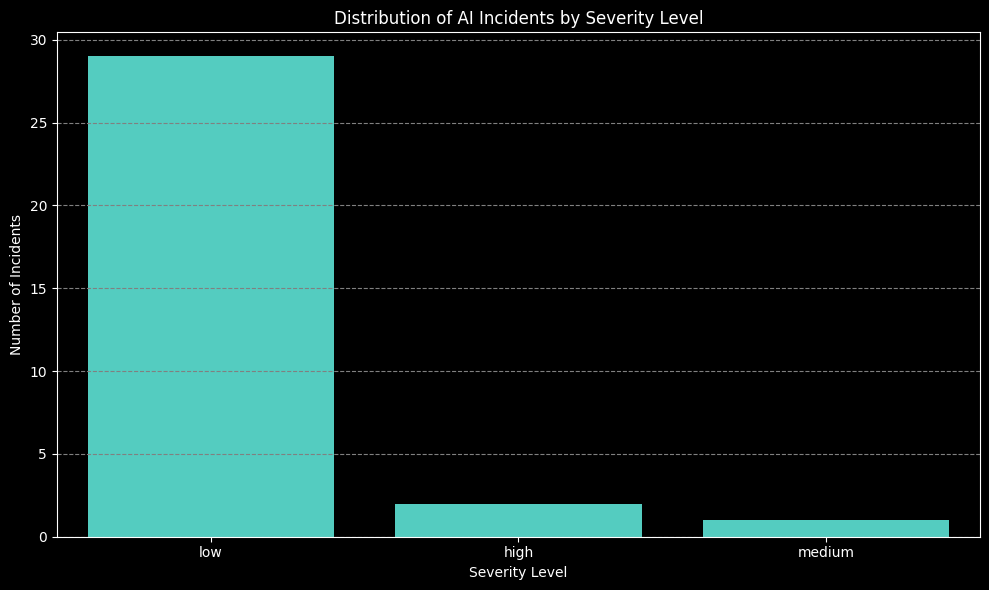

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set matplotlib style for dark mode
plt.style.use('dark_background')

# Plot for Incidents by Severity Level
plt.figure(figsize=(10, 6))
sns.barplot(x=severity_counts.index, y=severity_counts.values, color='#40E0D0') # Turquoise color

plt.title('Distribution of AI Incidents by Severity Level', color='white')
plt.xlabel('Severity Level', color='white')
plt.ylabel('Number of Incidents', color='white')
plt.xticks(color='white')
plt.yticks(color='white')
plt.grid(axis='y', color='gray', linestyle='--')

plt.tight_layout()
plt.show()

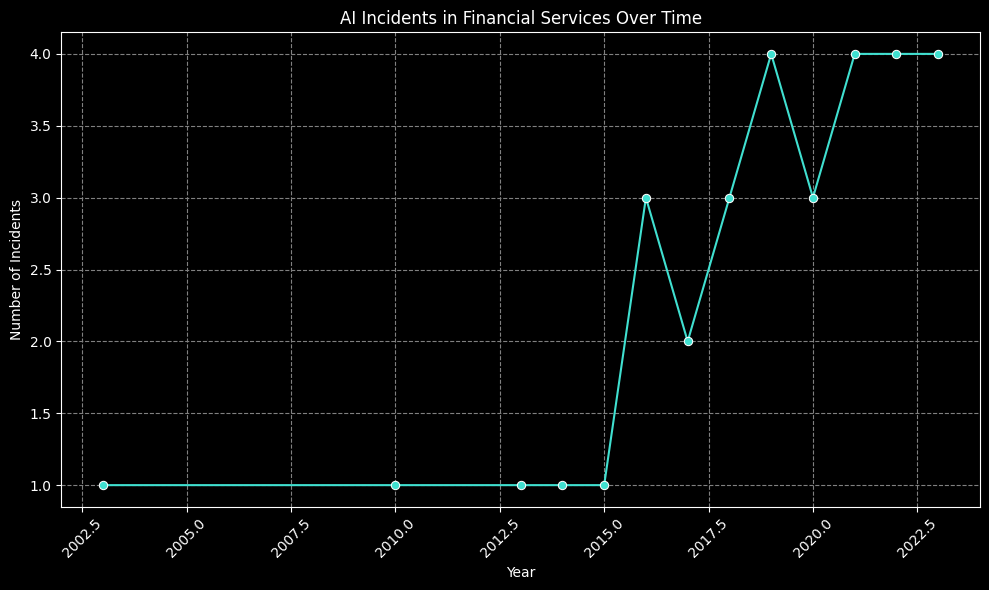

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set matplotlib style for dark mode
plt.style.use('dark_background')

plt.figure(figsize=(10, 6))
# Use a turquoise-like color for the line
sns.lineplot(x=incidents_by_year.index, y=incidents_by_year.values, marker='o', color='#40E0D0') # Turquoise color

plt.title('AI Incidents in Financial Services Over Time', color='white')
plt.xlabel('Year', color='white')
plt.ylabel('Number of Incidents', color='white')
plt.grid(True, color='gray', linestyle='--') # Adjust grid color for dark mode
plt.xticks(rotation=45, color='white')
plt.yticks(color='white')

plt.tight_layout()
plt.show()


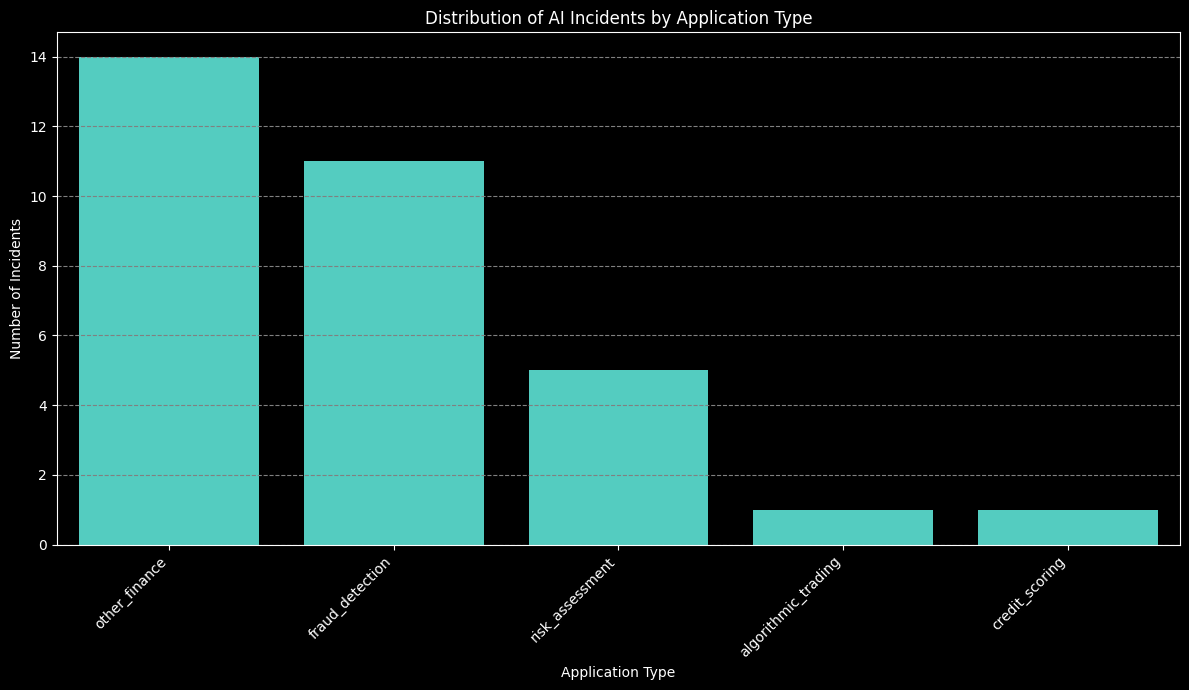

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set matplotlib style for dark mode
plt.style.use('dark_background')

plt.figure(figsize=(12, 7))
# Use a turquoise-like color for the bars
sns.barplot(x=application_counts.index, y=application_counts.values, color='#40E0D0') # Turquoise color

plt.title('Distribution of AI Incidents by Application Type', color='white')
plt.xlabel('Application Type', color='white')
plt.ylabel('Number of Incidents', color='white')
plt.xticks(rotation=45, ha='right', color='white') # Rotate labels for better readability
plt.yticks(color='white')
plt.grid(axis='y', color='gray', linestyle='--') # Adjust grid color for dark mode

plt.tight_layout()
plt.show()

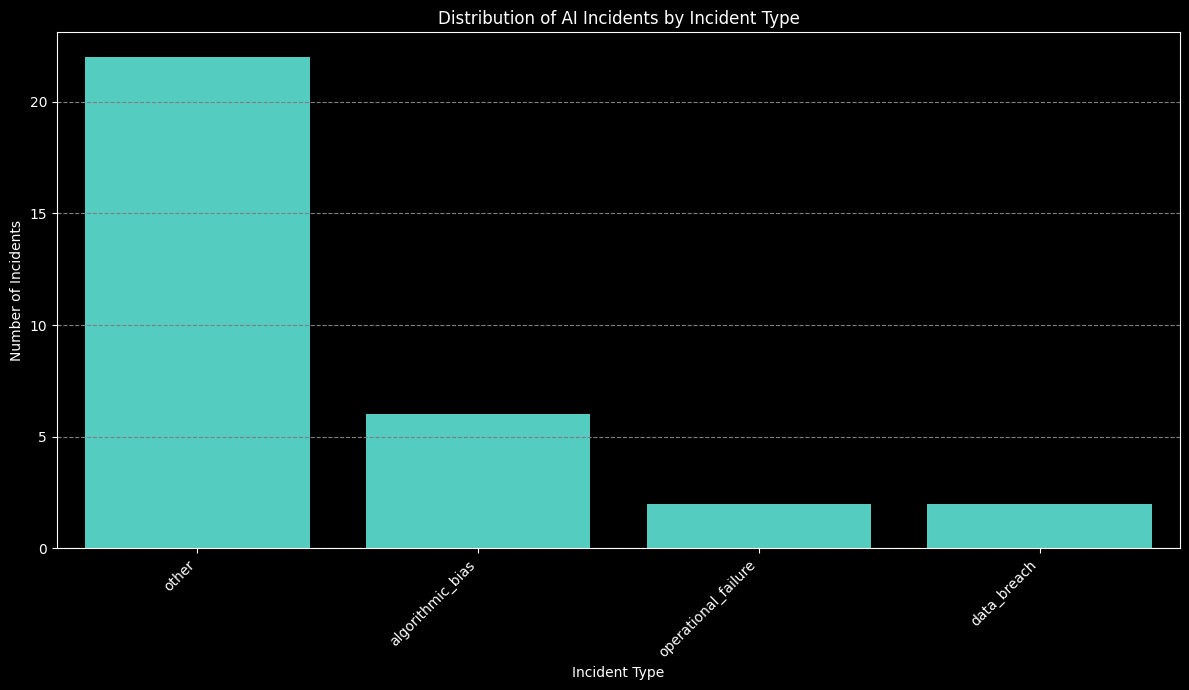

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set matplotlib style for dark mode
plt.style.use('dark_background')

# Plot for Incidents by Incident Type
plt.figure(figsize=(12, 7))
sns.barplot(x=incident_type_counts.index, y=incident_type_counts.values, color='#40E0D0') # Turquoise color

plt.title('Distribution of AI Incidents by Incident Type', color='white')
plt.xlabel('Incident Type', color='white')
plt.ylabel('Number of Incidents', color='white')
plt.xticks(rotation=45, ha='right', color='white')
plt.yticks(color='white')
plt.grid(axis='y', color='gray', linestyle='--')

plt.tight_layout()
plt.show()

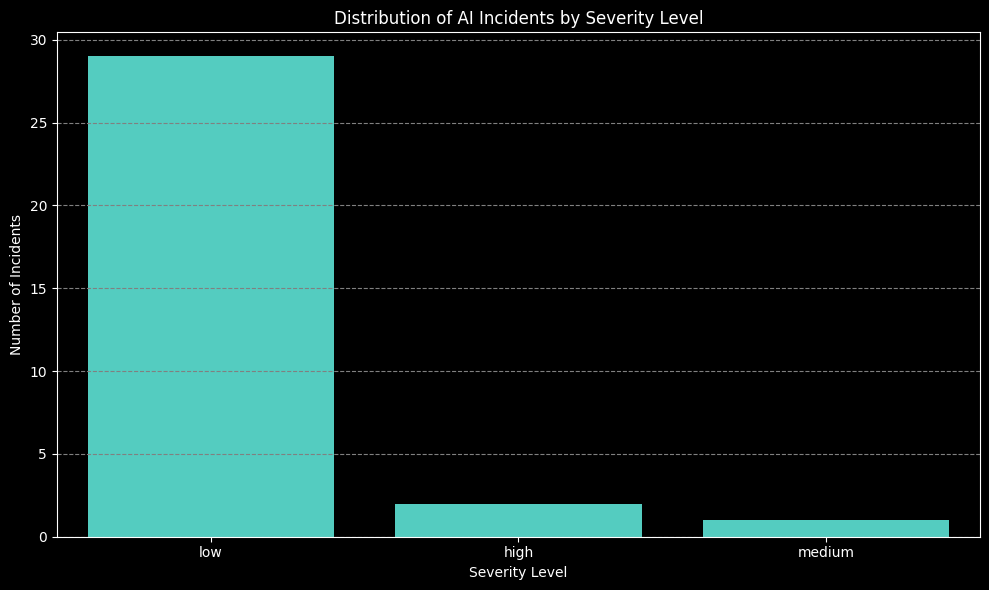

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set matplotlib style for dark mode
plt.style.use('dark_background')

# Plot for Incidents by Severity Level
plt.figure(figsize=(10, 6))
sns.barplot(x=severity_counts.index, y=severity_counts.values, color='#40E0D0') # Turquoise color

plt.title('Distribution of AI Incidents by Severity Level', color='white')
plt.xlabel('Severity Level', color='white')
plt.ylabel('Number of Incidents', color='white')
plt.xticks(color='white')
plt.yticks(color='white')
plt.grid(axis='y', color='gray', linestyle='--')

plt.tight_layout()
plt.show()

The analysis shows the distribution of AI incidents in financial services across different years, application types, incident types, and severity levels. It also provides a summary of regulatory and organizational responses. Key observations include:

**Incidents by Year:** There is an overall increase in reported incidents over time, with a notable surge starting in 2018.

**Incidents by Application Type:** “Other financial” and “fraud detection” are the most common application types, followed by “risk assessment.” “Algorithmic trading” and “credit scoring” have fewer reported incidents.

**Incidents by Incident Type:** Most incidents are categorized as “other,” followed by “algorithmic bias.” “Operational failure” and “data breach” are less frequent.

**Incidents by Severity Level:** Most incidents are classified as “low” severity, with some cases of “high” and “medium” severity.

**Regulatory and Organizational Responses:** Only three incidents involved a “regulatory investigation,” and no incidents resulted in “fines imposed,” “policy changes,” or “third-party audits” within this filtered dataset.


## 5. Save the Prepared Financial Incidents Dataset

Finally, the notebook exports the financial subset—already enriched with the derived variables—to a CSV file. This file (`incidents_finance_filtered.csv`) will be used as the standard input for the next notebooks in the project:

* A notebook for statistical analysis and pattern visualization of AI incidents in financial services.
* A notebook for predictive modeling to estimate the probability and severity of incidents based on the derived features.


In [ ]:
output_path = "incidents_finance_filtered.csv"
df_fin.to_csv(output_path, index=False)
print(f"Saved prepared dataset to: {output_path}")

Saved prepared dataset to: incidents_finance_filtered.csv


## Data Analysis Report: AI Incidents in Financial Services

This report presents the initial analysis of AI incidents, with a specific focus on the financial services sector. The objective of this phase was to transform a raw incident dataset into a clean and enriched dataset suitable for future statistical analysis and predictive modeling. The methodology included data loading and standardization, filtering for finance-related incidents, and the creation of derived variables to categorize events.

### 1. Data Overview

The original dataset contained **514 incidents**. After filtering using finance-related keywords, we identified **32 incidents** specific to the financial sector. This subset forms the basis for the subsequent analyses.

### 2. Key Findings from Descriptive Analysis

The initial descriptive analysis provided insights into the distribution and characteristics of AI incidents in the financial sector:

**Incidents by Year:**

An increase in the frequency of reported incidents was observed over time, with acceleration starting in 2018. This may indicate greater adoption of AI in the sector, increased awareness of incidents, or improved reporting practices. The data shows:

```
2003    1
2010    1
2013    1
2014    1
2015    1
2016    3
2017    2
2018    3
2019    4
2020    3
2021    4
2022    4
2023    4
```

**Incidents by Financial Application Type:**

The categories 'other_finance' and 'fraud_detection' are the most represented, followed by 'risk_assessment'. This suggests that fraud detection is a sensitive area for AI incidents, while many other financial applications are still broadly categorized.

```
other_finance          14
fraud_detection        11
risk_assessment         5
algorithmic_trading     1
credit_scoring          1
```

**Incidents by Incident Type:**

Most incidents were classified as 'other', indicating either the need to refine categories or that many incidents do not fit well into predefined common definitions. However, 'algorithmic_bias' emerges as the most frequent specific category, highlighting the importance of fairness in AI systems.

```
other                  22
algorithmic_bias        6
operational_failure     2
data_breach             2
```

**Incidents by Severity Level:**

The vast majority of incidents are classified as 'low' severity, with only a few cases of 'high' and 'medium' severity. This may reflect reporting practices or the perceived impact of incidents.

```
low       29
high       2
medium     1
```

**Regulatory and Organizational Responses:**

Interestingly, very few incidents in this subset resulted in explicit regulatory or organizational responses. Only 3 incidents triggered a 'regulatory_investigation', and none resulted in 'fine_imposed', 'policy_change', or 'third_party_audit'. This may indicate that many incidents are handled internally or that available documentation does not capture these actions.

```
regulatory_investigation    3
fine_imposed                0
policy_change               0
third_party_audit           0
```

### 3. Conclusion and Next Steps

This preparation and exploration phase provided valuable insights into the nature of AI incidents in financial services. The dataset `incidents_finance_filtered.csv`, enriched with `application_type`, `incident_type`, `customer_segment`, and `severity_level`, is now ready for the next stages of the project. Although heuristic, the created categories provide a solid starting point for deeper analysis. The next notebooks will focus on:

* **Advanced Statistical Analysis**: To identify more robust patterns and correlations.
* **Predictive Modeling**: To explore the possibility of predicting the probability and severity of future AI incidents in the financial sector.

These initial findings already point to the need for greater attention to algorithmic bias and more transparent documentation of incident responses within financial institutions.
